# Speech AI System: Voice Biometrics & Anti-Spoofing
Pipeline completo de dados, treino, avaliacao e predicao

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path.cwd()
sys.path.insert(0, str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.io import wavfile

from src import AudioProcessor, FeatureExtractor, AudioDataset, CNNAntiSpoofing, ModelTrainer, ModelEvaluator, AudioInference

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SR = 16000
N_MELS = 128

print(f'Device: {DEVICE}')
print(f'Sample Rate: {SR} Hz')
print('Setup OK')

Device: cpu
Sample Rate: 16000 Hz
Setup OK


## 1. Gerar Dados Dummy

In [2]:
Path('data/raw').mkdir(parents=True, exist_ok=True)
processor = AudioProcessor(sr=SR)

print('Gerando 30 arquivos de audio...')

for i in range(15):
    duration = 2.0
    t = np.linspace(0, duration, int(SR * duration))
    audio = np.sin(2 * np.pi * 200 * t) + 0.5 * np.sin(2 * np.pi * 400 * t)
    audio += 0.1 * np.random.randn(len(audio))
    audio = processor.normalize_audio(audio)
    audio = (audio * 32767).astype(np.int16)
    wavfile.write(f'data/raw/real_{i}.wav', SR, audio)

for i in range(15):
    duration = 2.0
    t = np.linspace(0, duration, int(SR * duration))
    audio = np.sin(2 * np.pi * 250 * t) + 0.3 * np.sin(2 * np.pi * 350 * t)
    audio = processor.normalize_audio(audio)
    audio = (audio * 32767).astype(np.int16)
    wavfile.write(f'data/raw/fake_{i}.wav', SR, audio)

print('OK: 30 arquivos criados')

Gerando 30 arquivos de audio...
OK: 30 arquivos criados


## 2. Preparar Dataset

In [3]:
def collate_fn_pad(batch):
    features_list = [item[0] for item in batch if item[0] is not None]
    labels_list = [item[1] for item in batch if item[0] is not None]
    
    if not features_list:
        return None, None
    
    max_len = max(f.shape[2] for f in features_list)
    padded_features = []
    
    for f in features_list:
        pad_len = max_len - f.shape[2]
        if pad_len > 0:
            f = torch.nn.functional.pad(f, (0, pad_len))
            padded_features.append(f.squeeze(0))
        else:
            padded_features.append(f.squeeze(0))
    
    features = torch.stack(padded_features, dim=0)
    features = features.unsqueeze(1)
    labels = torch.LongTensor(labels_list)
    
    return features, labels

audio_files = []
labels = []

for f in Path('data/raw').glob('*.wav'):
    labels.append(0 if 'real' in f.name else 1)
    audio_files.append(str(f))

print(f'Total: {len(audio_files)} arquivos')
print(f'Reais: {sum(1 for l in labels if l == 0)}')
print(f'Fakes: {sum(1 for l in labels if l == 1)}')

dataset = AudioDataset(
    audio_files=audio_files,
    labels=labels,
    sr=SR,
    n_mels=N_MELS,
    feature_type='mel',
    augmentation=True
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn_pad)
val_loader = DataLoader(val_dataset, batch_size=8, collate_fn=collate_fn_pad)

print(f'OK: Train {len(train_dataset)}, Val {len(val_dataset)}')

Total: 30 arquivos
Reais: 15
Fakes: 15
OK: Train 24, Val 6


## 3. Treinar Modelo

In [4]:
print('Treinando modelo...')
model = CNNAntiSpoofing().to(DEVICE)
trainer = ModelTrainer(model, device=DEVICE, lr=0.001)

history = trainer.train(train_loader, val_loader, epochs=5, save_dir='models')
print('OK: Treinamento completo')

Treinando modelo...

Epoch 1/5


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  4.98it/s]


  Train - Loss: 0.4126, Acc: 83.33%
  Val   - Loss: 0.4743, Acc: 100.00%
[OK] Modelo salvo em models/best_model.pt
  [BEST] Melhor modelo salvo! (Acc: 100.00%)

Epoch 2/5


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  3.73it/s]


  Train - Loss: 0.1030, Acc: 100.00%
  Val   - Loss: 0.2461, Acc: 100.00%

Epoch 3/5


...

  Train - Loss: 0.0362, Acc: 100.00%
  Val   - Loss: 0.1115, Acc: 100.00%

Epoch 4/5


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  3.49it/s]


  Train - Loss: 0.0389, Acc: 100.00%
  Val   - Loss: 0.0420, Acc: 100.00%

Epoch 5/5


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  5.38it/s]

  Train - Loss: 0.0424, Acc: 100.00%
  Val   - Loss: 0.0129, Acc: 100.00%
OK: Treinamento completo


## 4. Avaliar

In [5]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
val_loss, val_acc, val_preds, val_labels = trainer.evaluate(val_loader, criterion)

print(f'Loss: {val_loss:.4f}')
print(f'Accuracy: {val_acc:.2f}%')

model.eval()
all_scores = []
with torch.no_grad():
    for features, labels in val_loader:
        if features is None:
            continue
        features = features.to(DEVICE)
        outputs = model(features)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_scores.append(probs.cpu().numpy())

all_scores = np.vstack(all_scores)

evaluator = ModelEvaluator()
metrics = evaluator.comprehensive_evaluation(np.array(val_labels), np.array(val_preds), all_scores)
evaluator.print_metrics(metrics)

Evaluating: 100%|██████████| 1/1 [00:00<00:00,  4.66it/s]


Loss: 0.0116
Accuracy: 100.00%

[INFO] MÉTRICAS DE AVALIAÇÃO
Accuracy:     1.0000 (100.00%)
Precision:    1.0000
Recall:       1.0000
F1-Score:     1.0000
ROC-AUC:      1.0000
EER:          0.0000 (0.00%)
minDCF:       0.0000



## 5. Visualizar Features

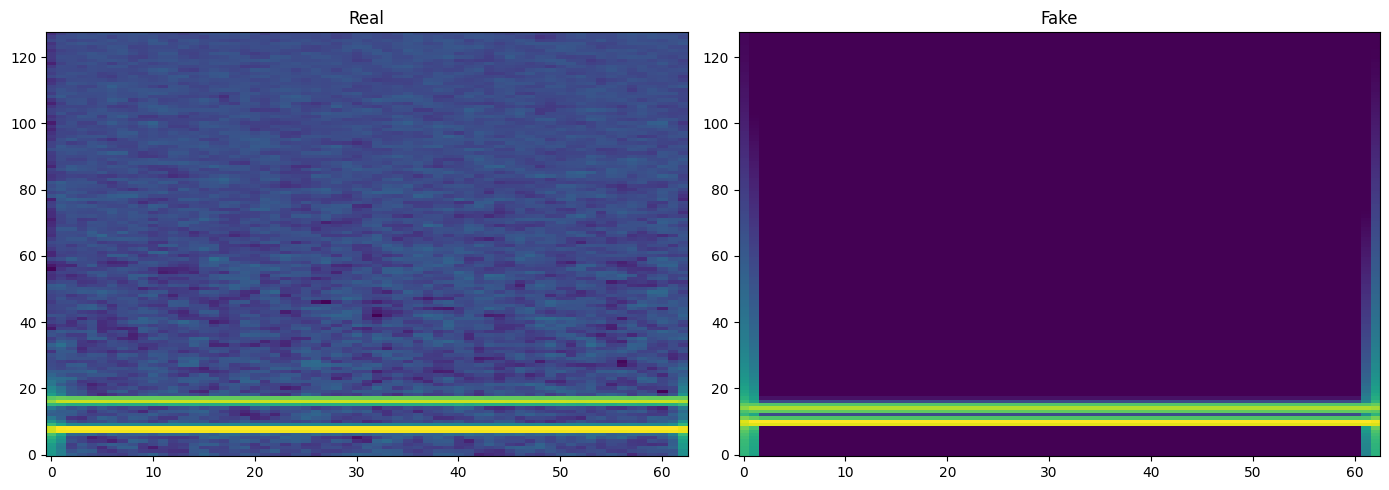

OK: Figura salva


In [6]:
extractor = FeatureExtractor(sr=SR, n_mels=N_MELS)
audio_real, _ = processor.load_audio('data/raw/real_0.wav', sr=SR)
audio_fake, _ = processor.load_audio('data/raw/fake_0.wav', sr=SR)

mel_real = extractor.extract_mel_spectrogram(audio_real)
mel_fake = extractor.extract_mel_spectrogram(audio_fake)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(mel_real, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Real')
axes[1].imshow(mel_fake, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Fake')
plt.tight_layout()

Path('results').mkdir(exist_ok=True)
plt.savefig('results/features.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK: Figura salva')

## 6. Training History

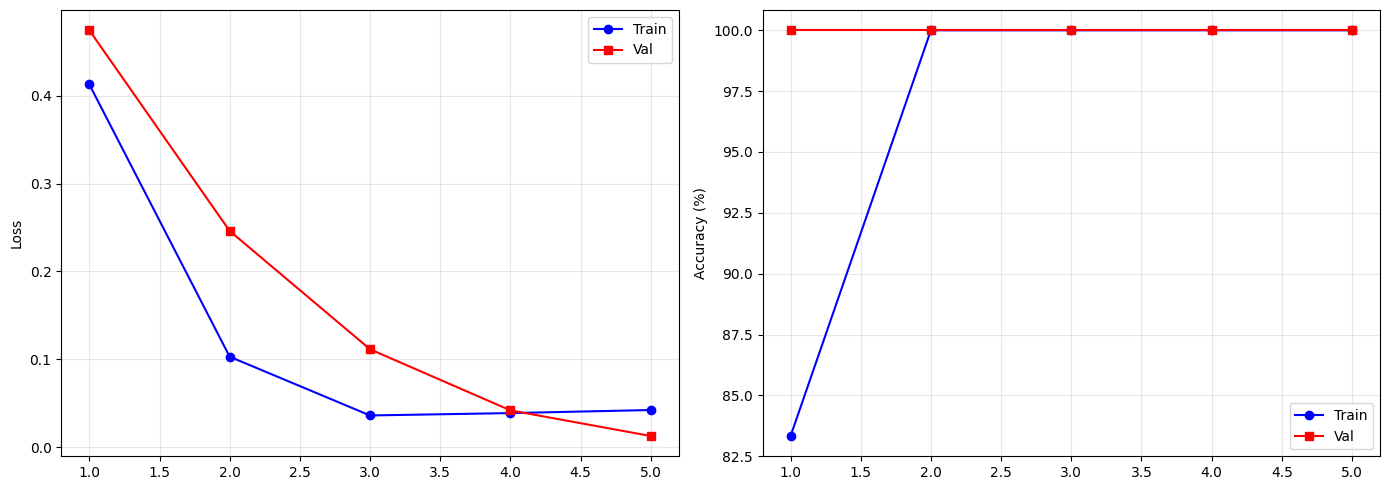

OK: Historico salvo


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/history.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK: Historico salvo')

## 7. Predicoes

In [8]:
inference = AudioInference(model_dir='models')
result = inference.predict_spoofing('data/raw/real_0.wav')

if 'error' not in result:
    print(f'Predicao: {result["prediction"].upper()}')
    print(f'Confianca: {result["confidence"]*100:.1f}%')
else:
    print(f'Erro: {result["error"]}')

[OK] Modelo anti-spoofing carregado
Predicao: REAL
Confianca: 97.8%


## 8. Salvar Modelos

In [9]:
import json

Path('models').mkdir(exist_ok=True)
trainer.save_model('models/anti_spoof_model.pt')

config = {'sample_rate': SR, 'n_mels': N_MELS, 'device': str(DEVICE)}
with open('models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('OK: Modelos salvos em models/')

[OK] Modelo salvo em models/anti_spoof_model.pt
OK: Modelos salvos em models/


## 9. Resumo

In [10]:
print('='*70)
print('PIPELINE COMPLETO EXECUTADO COM SUCESSO')
print('='*70)
print(f'Dataset: 30 arquivos (15 reais, 15 fake)')
print(f'Treino: {len(history["train_loss"])} epocas')
print(f'Accuracy: {max(history["val_acc"]):.2f}%')
print(f'EER: {metrics["eer"]*100:.2f}%')
print(f'ROC-AUC: {metrics["roc_auc"]:.4f}')
print(f'\nProximos passos:')
print(f'1. Treinar com ASVspoof 2019')
print(f'2. Deploy: python -m uvicorn api.main:app')
print(f'3. Predicoes: python src/predict.py --audio audio.wav')
print('='*70)

PIPELINE COMPLETO EXECUTADO COM SUCESSO
Dataset: 30 arquivos (15 reais, 15 fake)
Treino: 5 epocas
Accuracy: 100.00%
EER: 0.00%
ROC-AUC: 1.0000

Proximos passos:
1. Treinar com ASVspoof 2019
2. Deploy: python -m uvicorn api.main:app
3. Predicoes: python src/predict.py --audio audio.wav
